# 4. Metropolis–Hastings: `snia.bayes`

The sampler, checked first on targets whose answers are known exactly, then
applied to the Union2.1 posterior.

`snia.bayes` imports neither `snia.cosmology` nor `snia.data`. It takes any
callable returning a log density, which is what lets sections 2–6 compare
against distributions we know in closed form.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from snia.bayes.posterior import Posterior, UniformPrior
from snia.bayes.proposals import GaussianRandomWalk
from snia.bayes.samplers import MetropolisHastings, run_chains

plt.rcParams["figure.figsize"] = (7, 4)


def autocorrelation(chain, max_lag=60):
    # correlation of the chain with itself, lag by lag
    centred = chain - chain.mean()
    full = np.correlate(centred, centred, mode="full")
    from_zero_lag = full[len(centred) - 1:]
    return from_zero_lag[: max_lag + 1] / from_zero_lag[0]

## 1. The algorithm

Propose $\theta' \sim q(\cdot\mid\theta)$, then accept with

$$
\log u < \log\pi(\theta') - \log\pi(\theta)
+ \log q(\theta\mid\theta') - \log q(\theta'\mid\theta),
\qquad u \sim U(0,1).
$$

**Why it works.** The equilibrium flow is

$$
F(\theta\to\theta') = \pi(\theta)q(\theta'\mid\theta)\min[1, R]
= \min\big[\pi(\theta)q(\theta'\mid\theta),\ \pi(\theta')q(\theta\mid\theta')\big],
$$

which is unchanged when $\theta$ and $\theta'$ are swapped. So
$F(\theta\to\theta') = F(\theta'\to\theta)$ — detailed balance — and $\pi$ is
invariant. The evidence cancels in the ratio, so an unnormalized target suffices.

Three things the library takes care of:

* $\log\pi(\theta)$ is **cached**, so each step costs one target evaluation even
  after a rejection;
* a non-finite target (`-inf` or `NaN`) makes the comparison false, so it is a
  rejection rather than an error;
* on rejection the current state is **appended again** (section 5).

## 2. A one-dimensional target

Start with $\pi(x) = \mathcal{N}(0,1)$, where every answer is known.

In [2]:
log_normal = lambda theta: -0.5 * np.sum(np.asarray(theta) ** 2)

result = MetropolisHastings(
    log_target=log_normal,
    proposal=GaussianRandomWalk(cov=[[1.0]], scale=2.4),
).sample(initial_state=[3.0], n_steps=20000, rng=np.random.default_rng(0))

print(f"samples shape   {result.samples.shape}")
print(f"acceptance rate {result.acceptance_rate:.3f}")

samples shape   (20000, 1)
acceptance rate 0.440


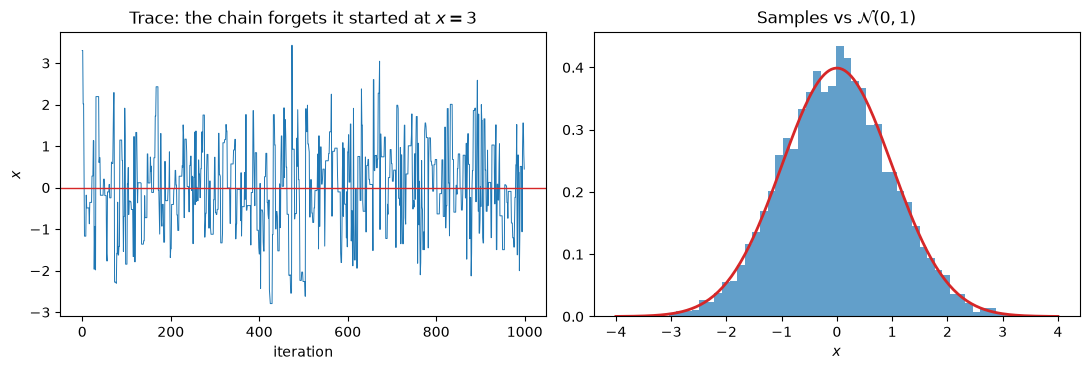

mean -0.0028  (truth 0)
std  0.9913  (truth 1)


In [3]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.plot(result.samples[:1000, 0], lw=0.7)
left.axhline(0, color="C3", lw=1)
left.set_xlabel("iteration")
left.set_ylabel("$x$")
left.set_title("Trace: the chain forgets it started at $x = 3$")

retained = result.samples[500:, 0]
right.hist(retained, bins=50, density=True, alpha=0.7)
grid = np.linspace(-4, 4, 200)
right.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "C3", lw=2)
right.set_xlabel("$x$")
right.set_title(r"Samples vs $\mathcal{N}(0,1)$")
plt.tight_layout()
plt.show()

print(f"mean {retained.mean():+.4f}  (truth 0)")
print(f"std  {retained.std():.4f}  (truth 1)")

## 3. The proposal scale

* **too small** — nearly everything is accepted, but the chain barely moves and
  successive samples are strongly correlated;
* **too large** — most proposals land where the density is negligible, so the
  chain sticks;
* **useful** — regular movement across the typical set.

The acceptance rate is a *symptom*, not the goal. What matters is how fast the
autocorrelation decays.

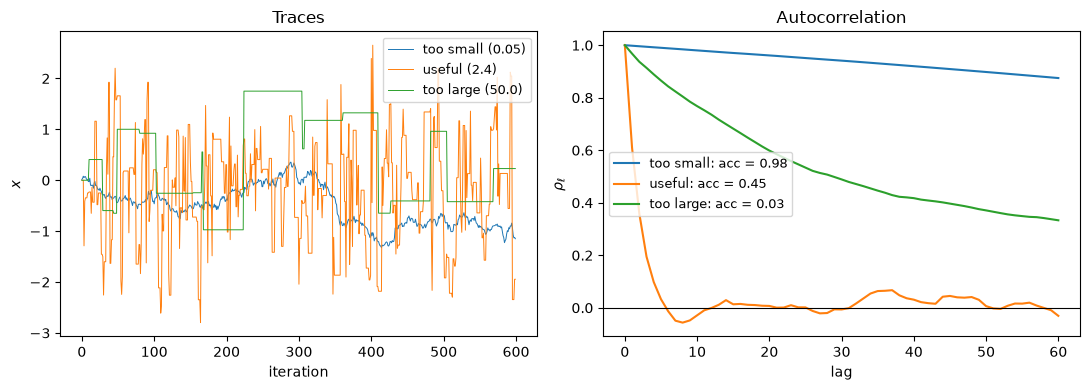

Both extremes sample the correct target and waste most of the effort.
Effective sample size quantifies this -- that is snia.diagnostics.


In [4]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

for scale, label in [(0.05, "too small"), (2.4, "useful"), (50.0, "too large")]:
    run = MetropolisHastings(log_normal, GaussianRandomWalk([[1.0]], scale)).sample(
        [0.0], 4000, np.random.default_rng(1)
    )
    chain = run.samples[:, 0]
    left.plot(chain[:600], lw=0.7, label=f"{label} ({scale})")
    right.plot(autocorrelation(chain), label=f"{label}: acc = {run.acceptance_rate:.2f}")

left.set_xlabel("iteration")
left.set_ylabel("$x$")
left.set_title("Traces")
left.legend(fontsize=9)

right.axhline(0, color="k", lw=0.8)
right.set_xlabel("lag")
right.set_ylabel(r"$\rho_\ell$")
right.set_title("Autocorrelation")
right.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Both extremes sample the correct target and waste most of the effort.")
print("Effective sample size quantifies this -- that is snia.diagnostics.")

## 4. Correlated posteriors need correlated proposals

An axis-aligned proposal wastes attempts across a narrow degeneracy. The
supernova posterior has exactly this shape, so the proposal covariance should
approximate the posterior covariance.

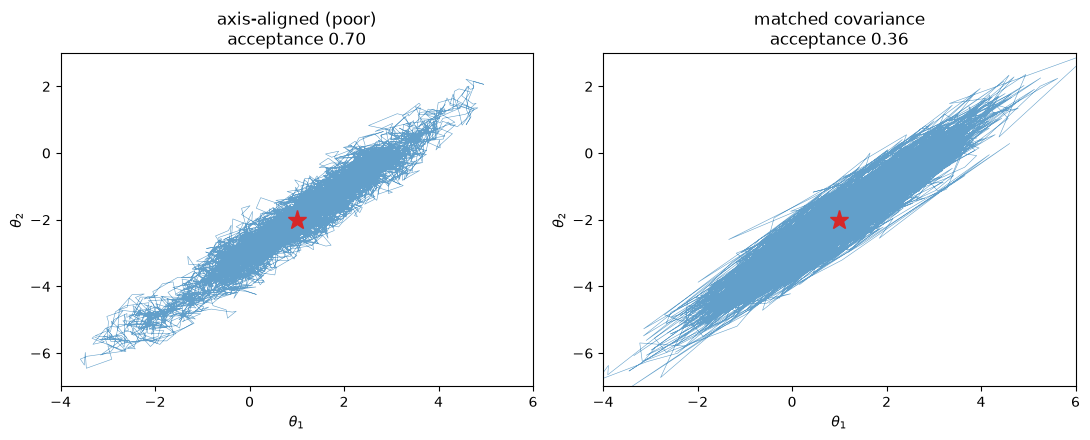

In [5]:
mean = np.array([1.0, -2.0])
covariance = np.array([[2.0, 1.9], [1.9, 2.0]])        # strongly degenerate
precision = np.linalg.inv(covariance)

def log_banana(theta):
    offset = np.asarray(theta) - mean
    return -0.5 * offset @ precision @ offset

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
proposals = [("axis-aligned (poor)", GaussianRandomWalk(np.eye(2) * 0.1)),
             ("matched covariance", GaussianRandomWalk(covariance, scale=1.7))]

for axis, (label, proposal) in zip(axes, proposals):
    run = MetropolisHastings(log_banana, proposal).sample(
        mean, 8000, np.random.default_rng(2)
    )
    axis.plot(run.samples[:, 0], run.samples[:, 1], lw=0.4, alpha=0.7)
    axis.plot(*mean, "C3*", ms=14)
    axis.set_xlim(-4, 6)
    axis.set_ylim(-7, 3)
    axis.set_xlabel(r"$\theta_1$")
    axis.set_ylabel(r"$\theta_2$")
    axis.set_title(f"{label}\nacceptance {run.acceptance_rate:.2f}")
plt.tight_layout()
plt.show()

## 5. A rejection is still a sample

On rejection the current state must be recorded **again**. Keeping only the
accepted proposals changes how often each region is visited and biases every
estimate.

In [6]:
print(f"{'scale':>7} {'acceptance':>11} {'full chain':>12} {'accepted only':>15}")
for scale in [0.5, 2.0, 6.0]:
    run = MetropolisHastings(log_normal, GaussianRandomWalk([[1.0]], scale)).sample(
        [0.0], 60000, np.random.default_rng(3)
    )
    full = run.samples[:, 0]
    accepted_only = run.samples[run.accepted][:, 0]
    print(f"{scale:7.1f} {run.acceptance_rate:11.3f} {full.std():12.4f} {accepted_only.std():15.4f}")

print("\nstandard deviation, truth = 1.0000")
print("The full chain is right at every scale. The accepted-only subset is not,")
print("and both the size and the sign of its error depend on the proposal.")

  scale  acceptance   full chain   accepted only


    0.5       0.845       0.9958          0.9566
    2.0       0.500       1.0084          1.0518


    6.0       0.205       0.9898          1.1244

standard deviation, truth = 1.0000
The full chain is right at every scale. The accepted-only subset is not,
and both the size and the sign of its error depend on the proposal.


## 6. The Hastings ratio

For a proposal centred on the current state, $q(\theta'\mid\theta) = q(\theta\mid\theta')$
and the proposal terms cancel — the *Metropolis* special case.
`GaussianRandomWalk` sets `is_symmetric = True`, so the sampler skips them.

For anything else the correction is required. An autoregressive proposal
$q(\theta'\mid\theta) = \mathcal{N}(\theta';\,a\theta,\ \sigma^{2})$ with
$a \neq 1$ pulls toward the origin and is asymmetric. Declaring it symmetric
makes the library skip the correction, which shows what the ratio is doing.

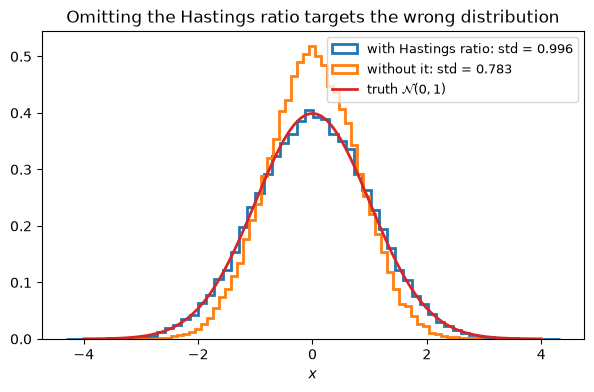

The uncorrected chain looks perfectly healthy -- stationary trace,
sensible acceptance rate -- and is about 20% too narrow.


In [7]:
class Autoregressive:
    is_symmetric = False

    def __init__(self, drift, sigma):
        self.drift = drift
        self.sigma = sigma

    def propose(self, state, rng):
        return self.drift * np.asarray(state) + self.sigma * rng.standard_normal(1)

    def logpdf(self, target, given):
        offset = np.asarray(target) - self.drift * np.asarray(given)
        return -0.5 * (offset @ offset) / self.sigma**2


class WronglyDeclaredSymmetric(Autoregressive):
    is_symmetric = True        # the sampler now skips the Hastings ratio


for proposal_class, label in [(Autoregressive, "with Hastings ratio"),
                              (WronglyDeclaredSymmetric, "without it")]:
    run = MetropolisHastings(log_normal, proposal_class(0.3, 1.2)).sample(
        [0.0], 60000, np.random.default_rng(4)
    )
    chain = run.samples[2000:, 0]
    plt.hist(chain, bins=60, density=True, histtype="step", lw=2,
             label=f"{label}: std = {chain.std():.3f}")

grid = np.linspace(-4, 4, 200)
plt.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "C3", lw=2,
         label=r"truth $\mathcal{N}(0,1)$")
plt.xlabel("$x$")
plt.legend(fontsize=9)
plt.title("Omitting the Hastings ratio targets the wrong distribution")
plt.show()

print("The uncorrected chain looks perfectly healthy -- stationary trace,")
print("sensible acceptance rate -- and is about 20% too narrow.")

## 7. Reproducibility

The sampler requires an explicit `numpy.random.Generator` and never uses the
global `np.random`.

In [8]:
proposal = GaussianRandomWalk(covariance, scale=1.7)
first = MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 1000, np.random.default_rng(42))
again = MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 1000, np.random.default_rng(42))
print("same seed, byte-identical:", np.array_equal(first.samples, again.samples))

try:
    MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 10, rng=42)
except TypeError as error:
    print("a bare integer seed is refused:", error)

same seed, byte-identical: True
a bare integer seed is refused: pass an explicit numpy.random.Generator, e.g. np.random.default_rng(seed); the global np.random is never used


## 8. The Union2.1 posterior

The workflow is the one from the lecture: **tune during warm-up, then freeze**.
Adapting the proposal while collecting samples would break the Markov property.

In [9]:
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood

z, mu, cov = load_union21()
likelihood = Union21Likelihood(z, mu, cov)
prior = UniformPrior(lower=[0.0, -1.0], upper=[2.0, 3.0])    # the exercise's box
posterior = Posterior(likelihood.log_likelihood, prior)

print("posterior at LCDM:", posterior([0.3, 0.7]))
print("posterior outside the box:", posterior([5.0, 0.7]))

posterior at LCDM: -272.5613707336597
posterior outside the box: -inf


In [10]:
# Warm-up: a crude proposal, used only to LEARN the shape of the posterior.
warmup = MetropolisHastings(
    posterior, GaussianRandomWalk(np.diag([0.05**2, 0.08**2]))
).sample([0.3, 0.7], 4000, np.random.default_rng(0))

tuned_covariance = np.cov(warmup.samples[1000:].T)     # frozen from here on

print(f"warm-up acceptance {warmup.acceptance_rate:.3f}")
print("tuned proposal covariance:")
print(tuned_covariance)

warm-up acceptance 0.660
tuned proposal covariance:
[[0.0131547  0.01978836]
 [0.01978836 0.04460138]]


In [11]:
production = run_chains(
    posterior,
    GaussianRandomWalk(tuned_covariance, scale=1.7),      # frozen, not adapting
    initial_states=[[0.2, 0.5], [0.45, 0.95], [0.1, 0.85], [0.5, 0.6]],
    n_steps=20000,
    rng=np.random.default_rng(1),
)
retained = production.burned(2000)
samples = retained.flat()

print(f"samples shape {retained.samples.shape}   (chains, steps, parameters)")
print(f"acceptance    {np.round(production.acceptance_rate, 3)}\n")

omega_m, omega_lambda = samples[:, 0], samples[:, 1]
print(f"Omega_m = {omega_m.mean():+.4f} +- {omega_m.std():.4f}")
print(f"Omega_L = {omega_lambda.mean():+.4f} +- {omega_lambda.std():.4f}")
print(f"Omega_k = {(1 - omega_m - omega_lambda).mean():+.4f} +- {(1 - omega_m - omega_lambda).std():.4f}")
print(f"q0      = {(omega_m / 2 - omega_lambda).mean():+.4f} +- {(omega_m / 2 - omega_lambda).std():.4f}")

samples shape (4, 18000, 2)   (chains, steps, parameters)
acceptance    [0.338 0.328 0.335 0.34 ]

Omega_m = +0.2798 +- 0.1120
Omega_L = +0.6590 +- 0.2095
Omega_k = +0.0612 +- 0.3098
q0      = -0.5191 +- 0.1652


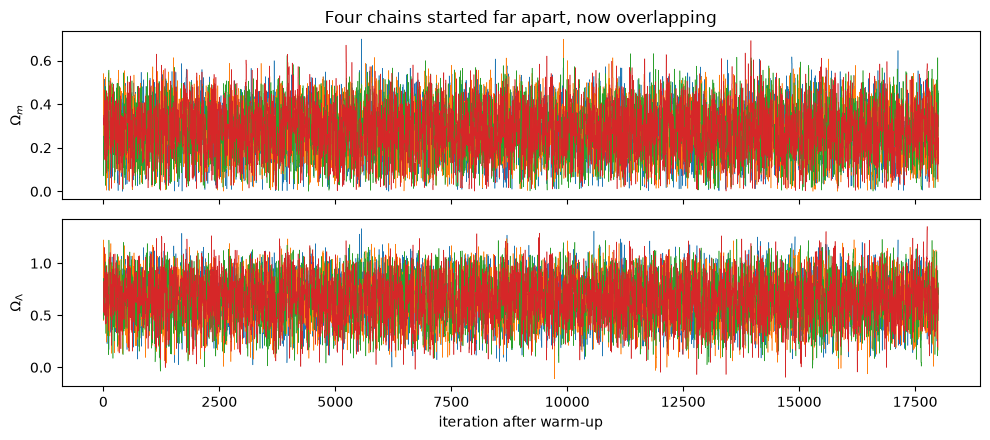

In [12]:
figure, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
for chain in range(retained.n_chains):
    axes[0].plot(retained.samples[chain, :, 0], lw=0.4)
    axes[1].plot(retained.samples[chain, :, 1], lw=0.4)
axes[0].set_ylabel(r"$\Omega_m$")
axes[1].set_ylabel(r"$\Omega_\Lambda$")
axes[1].set_xlabel("iteration after warm-up")
axes[0].set_title("Four chains started far apart, now overlapping")
plt.tight_layout()
plt.show()

### Does the sampler reproduce the brute-force grid?

Notebook 3 mapped $\chi^2$ on a grid. The MCMC must agree with it.

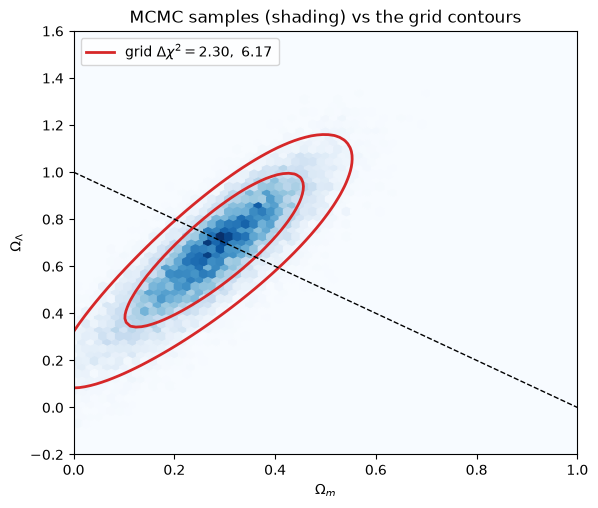

In [13]:
omega_m_axis = np.linspace(0.0, 1.0, 90)
omega_lambda_axis = np.linspace(-0.2, 1.6, 110)
chi2 = np.array([[likelihood.chi2((om, ol)) for om in omega_m_axis]
                 for ol in omega_lambda_axis])
chi2 -= chi2[np.isfinite(chi2)].min()

plt.figure(figsize=(6.5, 5.5))
plt.hexbin(omega_m, omega_lambda, gridsize=60, cmap="Blues",
           extent=(0, 1, -0.2, 1.6))
plt.contour(omega_m_axis, omega_lambda_axis, chi2, levels=[2.30, 6.17],
            colors="C3", linewidths=2)
plt.plot([0, 1], [1, 0], "k--", lw=1)
plt.plot([], [], "C3-", lw=2, label=r"grid $\Delta\chi^2 = 2.30,\ 6.17$")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\Omega_\Lambda$")
plt.title("MCMC samples (shading) vs the grid contours")
plt.legend(loc="upper left")
plt.show()

## 9. Cross-check: sample $\mathcal{M}$ instead of marginalizing it

The analytic result $\chi^2 = A - B^2/E$ assumes a flat prior on $\mathcal{M}$.
Running a **three-parameter** chain with $\mathcal{M}$ sampled must give the same
$(\Omega_m, \Omega_\Lambda)$ contours. A sign error in $B$, or a swapped
residual convention, would separate them.

In [14]:
prior_3d = UniformPrior([0.0, -1.0, 41.0], [2.0, 3.0, 45.0])
posterior_3d = Posterior(
    lambda theta: -0.5 * likelihood.chi2_at_offset(theta[:2], theta[2]),
    prior_3d,
)

start_covariance = np.zeros((3, 3))
start_covariance[:2, :2] = tuned_covariance
start_covariance[2, 2] = 0.004**2

warmup_3d = MetropolisHastings(posterior_3d, GaussianRandomWalk(start_covariance)).sample(
    [0.3, 0.7, 43.17], 6000, np.random.default_rng(2)
)

production_3d = run_chains(
    posterior_3d,
    GaussianRandomWalk(np.cov(warmup_3d.samples[1500:].T), scale=1.4),
    [[0.2, 0.5, 43.1], [0.45, 0.95, 43.2], [0.1, 0.85, 43.15], [0.5, 0.6, 43.25]],
    30000,
    np.random.default_rng(3),
)
samples_3d = production_3d.burned(3000).flat()

print(f"{'':10s} {'2 parameters':>22s} {'3 parameters':>22s}")
for column, name in [(0, "Omega_m"), (1, "Omega_L")]:
    two, three = samples[:, column], samples_3d[:, column]
    print(f"{name:10s} {two.mean():10.4f} +- {two.std():.4f} "
          f"{three.mean():10.4f} +- {three.std():.4f}")
print(f"\nM sampled  = {samples_3d[:, 2].mean():.4f} +- {samples_3d[:, 2].std():.4f}")
print(f"M analytic = {likelihood.m_offset((0.295, 0.705)):.4f}   (B/E)")

                     2 parameters           3 parameters
Omega_m        0.2798 +- 0.1120     0.2796 +- 0.1119
Omega_L        0.6590 +- 0.2095     0.6594 +- 0.2081

M sampled  = 43.1739 +- 0.0325
M analytic = 43.1683   (B/E)


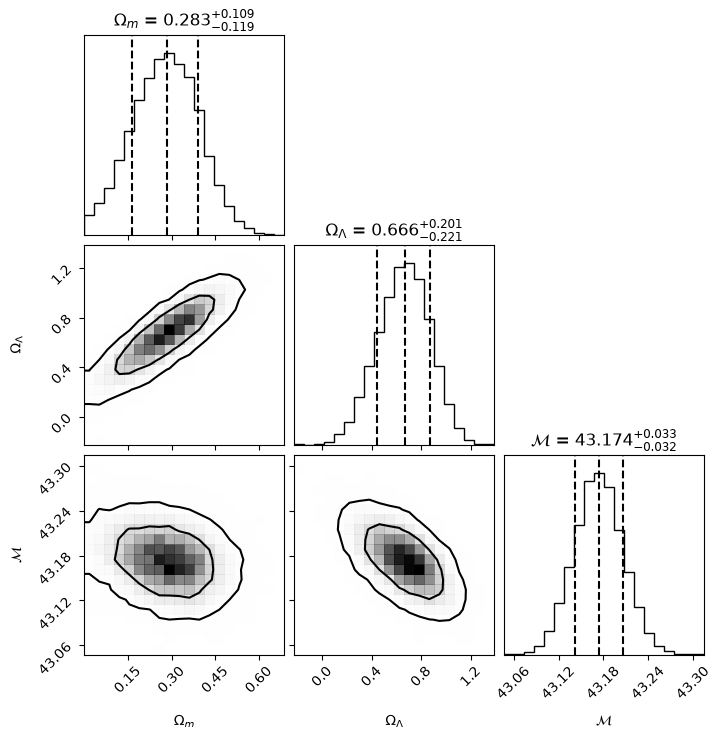

In [15]:
import corner

figure = corner.corner(
    samples_3d,
    labels=[r"$\Omega_m$", r"$\Omega_\Lambda$", r"$\mathcal{M}$"],
    levels=(0.683, 0.954),
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    plot_datapoints=False,
)
plt.show()

The two runs agree to about 3% of one posterior standard deviation. Repeating
both over six seed pairs, the difference averages $0.8$ MCSE with scatter $1.1$
— Monte Carlo noise, not a systematic offset, which would instead show a large
mean with small scatter.

## Summary

| object | role |
| --- | --- |
| `UniformPrior(lower, upper)` | flat box prior, `-inf` outside |
| `Posterior(log_likelihood, log_prior)` | their sum, skipping the likelihood when the prior already rejects |
| `GaussianRandomWalk(cov, scale)` | correlated random walk, factored once |
| `MetropolisHastings(log_target, proposal).sample(...)` | one chain |
| `run_chains(...)` | dispersed chains, shape `(chains, steps, parameters)` |

Union2.1 gives $\Omega_m \approx 0.28 \pm 0.11$ and
$\Omega_\Lambda \approx 0.66 \pm 0.21$, consistent with the grid and with
flatness.

**Still missing:** nothing here tests whether the chains have actually
converged. That is `snia.diagnostics` — split-$\hat{R}$, ESS and MCSE, and the
Dunkley power spectrum — the next milestone.
